In [10]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()

# Read uploaded file
df = pd.read_csv("iris (1).csv")

print(df.head())

Saving iris (1).csv to iris (1) (2).csv
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


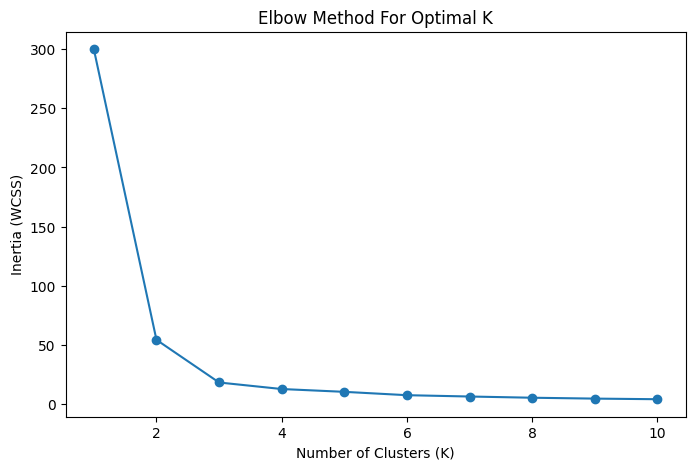

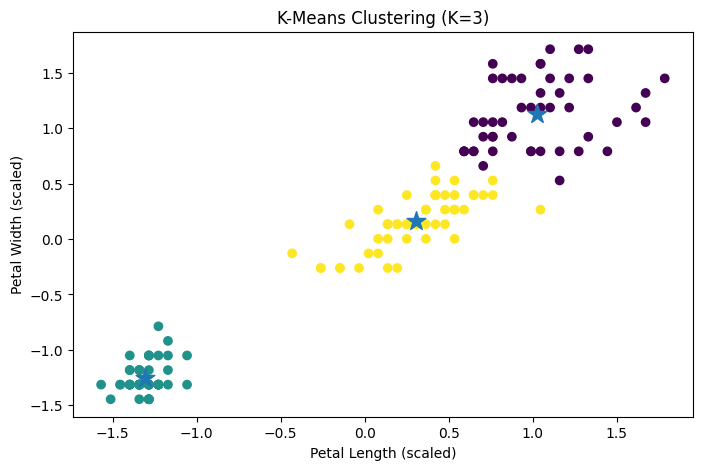

In [11]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Load dataset
df = pd.read_csv("iris (1).csv")

# Step 2: Select only Petal Length & Petal Width
X = df[['petal_length', 'petal_width']]

# Step 3: Preprocessing (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 4: Elbow Method
# -------------------------------
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.show()

# -------------------------------
# Step 5: Apply K-Means (choose optimal K)
# -------------------------------
# From elbow plot, K ≈ 3 (expected for Iris)
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_pred

# -------------------------------
# Step 6: Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200)

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clustering (K=3)')
plt.show()